In [1]:
pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


SUMMARY INFO
numerical data: Volume issued in ccy and USD, Maturity (years)
class data: bond type, bond theme, issuer type, issuer jurisdiction, framework link, last published date converted to bool for ext review [may not indicate this]
id data: bond handle, rang of IDs, issuer name
dates: Issuance and Maturity dates

Missing data: see box below & when Framework link is missing - what to conclude about these bonds.

Added cols: gbtp_alcns_df['Maturity (years)']

Outliers: yes >> see boxplots vol & mat years

ALIGN WITH QUAL RESEARCH
 - CBI
 - META-ANALYSIS
 -    Issuer jurisdiction (geog / cross with category), Maturity (geog / cross with category), Issuer type (meta analysis narrower)
 -    

**MISSING DATA QSTNS**

**bonds w'out issuance date & volume** - same popn? - inspect in excel - yes 21 records and same population. potentially exclude as a small number 7.78%
bonds with maturity date but no issuance date? a third of the rows w'out issuance date have a maturity date into the future, suggesting the null issuance date is bad data
All 21 can be searched by their handle on GBTP and data repaired by hand fairly quickly

**does every bond have either an ISIN, FIGI, CUSIP or Ticker? - yes.** Could create a waterfall logic & new attribute

consider fixing data in excel since these techniques go beyond what was taught in the program

In [2]:
import pandas as pd
gbtp_bonds_data = pd.read_csv('bonds.csv')
gbtp_bonds_df = pd.DataFrame(gbtp_bonds_data)
gbtp_bonds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Link                     270 non-null    str    
 1   Handle                   270 non-null    str    
 2   ISIN                     225 non-null    str    
 3   FIGI                     115 non-null    str    
 4   CUSIP                    18 non-null     str    
 5   Ticker                   104 non-null    str    
 6   Name                     270 non-null    str    
 7   Fund                     270 non-null    str    
 8   Fund handle              76 non-null     str    
 9   Fund link                76 non-null     str    
 10  Issuance date (date)     249 non-null    str    
 11  Maturity date (date)     258 non-null    str    
 12  Last published (date)    132 non-null    str    
 13  Bond type                270 non-null    str    
 14  Bond theme               270 non-null

In [3]:
gbtp_bonds_df.describe()

,Volume in bond currency,Volume in USD
count,2.490000e+02,2.490000e+02
mean,2.363314e+10,1.752067e+08
std,1.457902e+11,3.328389e+08
min,2.000000e+02,3.900000e+01
25%,3.696225e+07,1.462077e+07
50%,2.192705e+08,5.400000e+07
75%,7.500000e+08,1.536700e+08
max,1.985525e+12,2.318357e+09


In [4]:
gbtp_bonds_df.head()

,Link,Handle,ISIN,FIGI,CUSIP,Ticker,Name,Fund,Fund handle,Fund link,...,Last published (date),Bond type,Bond theme,Issuer name,Issuer type,Issuer jurisdiction,Framework link,Bond currency,Volume in bond currency,Volume in USD
0,https://www.greenbondtransparency.com/bond-inf...,9bd98e9cc0fd42a69775ddbd0c63147a,BRERENDBS073,NaN,NaN,NaN,Terceira Emissão De Debêntures Simples Da Eren...,No,NaN,NaN,...,2023-01-12 14:48:04.273412,unspecified,green,Total Eren,Non-Financial Corporate,Brazil,NaN,BRL,280000000.0,6.515264e+07
1,https://www.greenbondtransparency.com/bond-inf...,e6bb16f3d1e04ba789445370e5e99dc0,ARENEY560035,NaN,NaN,GYC2D CLASE III,ON 360 ENERGY SOLAR CLASE 3,No,NaN,NaN,...,2023-04-10 15:30:34.908014,unspecified,green,360 Energy Solar S.A.,Non-Financial Corporate,Argentina,NaN,USD,60000000.0,6.000000e+07
2,https://www.greenbondtransparency.com/bond-inf...,82f9c056cca1404e906b6d3270884a77,PAL3009913J3,NaN,NaN,NaN,CIFI Serie J,No,c8db70a600e4496aa0bdff98338e72ee,https://www.greenbondtransparency.com/bond-inf...,...,2025-10-30 16:13:37.098202,unspecified,green,Corporación Interamericana para el Financiamie...,Financial Corporate,Panama,https://www.greenbondtransparency.com/download...,USD,2000000.0,2.000000e+06
3,https://www.greenbondtransparency.com/bond-inf...,3e001fbc60b6457dbbb4e67ee69152c0,CL0002521988,NaN,NaN,NaN,BAGUA-AE,No,NaN,NaN,...,NaN,Unsecured,green,Aguas Andinas,Non-Financial Corporate,Chile,https://www.greenbondtransparency.com/download...,CLF,2000000.0,8.150633e+07
4,https://www.greenbondtransparency.com/bond-inf...,14cdc800b4464301a71619d0ffe527a8,CH1191066278,BBG0180P8YS2,NaN,CABEI 1.5462 11,Second Swiss Green Bond,No,NaN,NaN,...,2023-01-26 21:41:51.424408,unspecified,green,Central American Bank for Economic Integration...,Development Bank,Supranational,https://www.greenbondtransparency.com/download...,CHF,155000000.0,1.585840e+08


In [5]:
gbtp_bonds_df.isnull().sum()

Link                         0
Handle                       0
ISIN                        45
FIGI                       155
CUSIP                      252
Ticker                     166
Name                         0
Fund                         0
Fund handle                194
Fund link                  194
Issuance date (date)        21
Maturity date (date)        12
Last published (date)      138
Bond type                    0
Bond theme                   0
Issuer name                  0
Issuer type                  0
Issuer jurisdiction          0
Framework link             121
Bond currency                0
Volume in bond currency     21
Volume in USD               21
dtype: int64

In [6]:
pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


play around with different stats to decide what info is most useful (seaborn histograms)
also explain the significance of the kde=True and why it's appropriate for this data
play around with fig.set... functions

<Axes: xlabel='Volume in USD', ylabel='Density'>

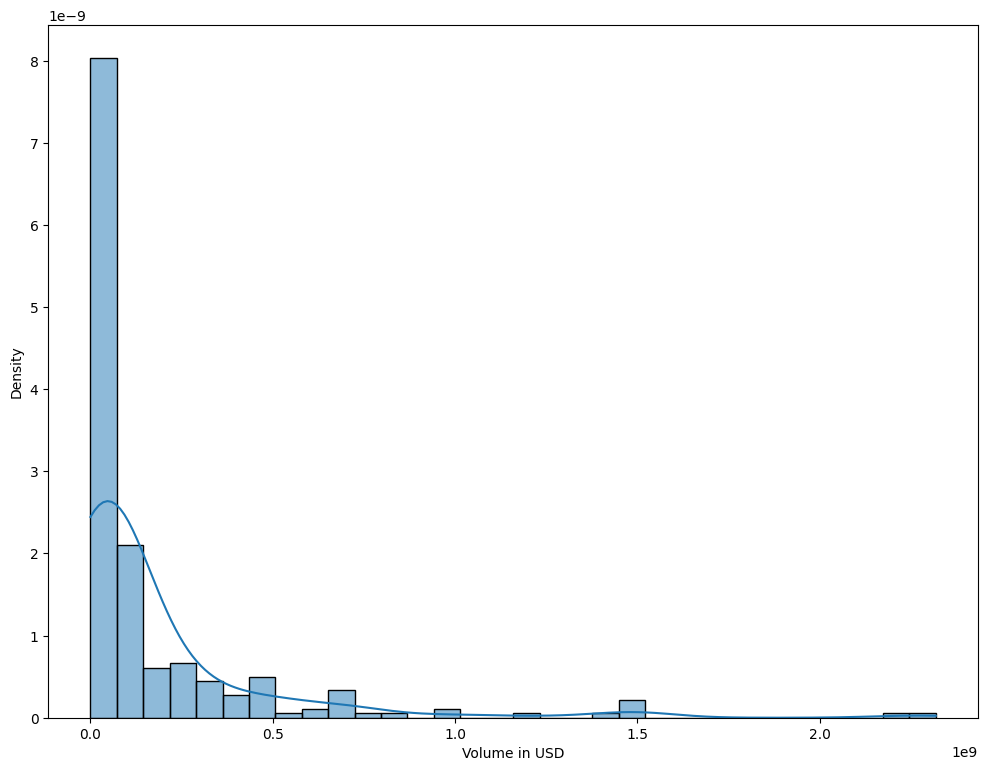

In [8]:
from matplotlib import pyplot as plt
%matplotlib inline

import seaborn as sns
fig, ax = plt.subplots()
fig.set_size_inches(12,9)
sns.histplot(gbtp_bonds_df['Volume in USD'], stat='density',kde=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'Argentina'),
  Text(2, 0, 'Panama'),
  Text(3, 0, 'Chile'),
  Text(4, 0, 'Supranational'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'Colombia'),
  Text(7, 0, 'Barbados'),
  Text(8, 0, 'Ecuador'),
  Text(9, 0, 'Costa Rica'),
  Text(10, 0, 'Dominican Republic'),
  Text(11, 0, 'Peru'),
  Text(12, 0, 'Uruguay'),
  Text(13, 0, 'Bolivia'),
  Text(14, 0, 'Paraguay')])

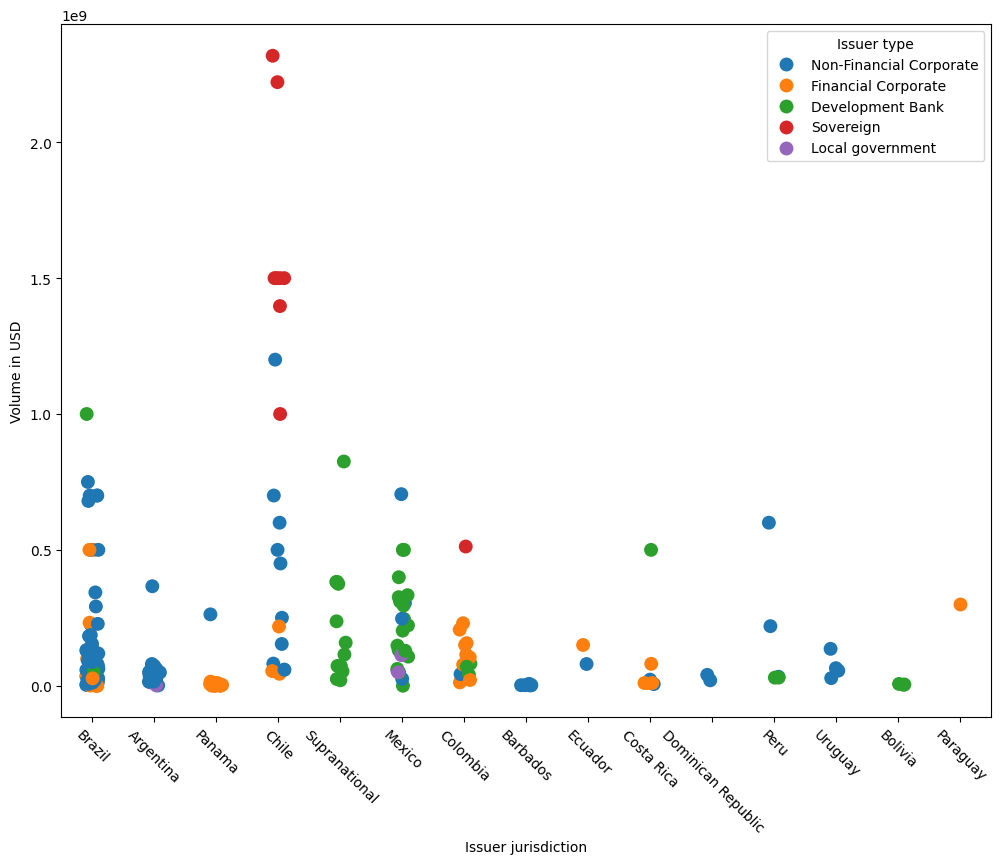

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='Issuer jurisdiction', y='Volume in USD', data= gbtp_bonds_df, hue='Issuer type', size=10)
plt.xticks(rotation=-45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'Argentina'),
  Text(2, 0, 'Panama'),
  Text(3, 0, 'Chile'),
  Text(4, 0, 'Supranational'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'Colombia'),
  Text(7, 0, 'Barbados'),
  Text(8, 0, 'Ecuador'),
  Text(9, 0, 'Costa Rica'),
  Text(10, 0, 'Dominican Republic'),
  Text(11, 0, 'Peru'),
  Text(12, 0, 'Uruguay'),
  Text(13, 0, 'Bolivia'),
  Text(14, 0, 'Paraguay')])

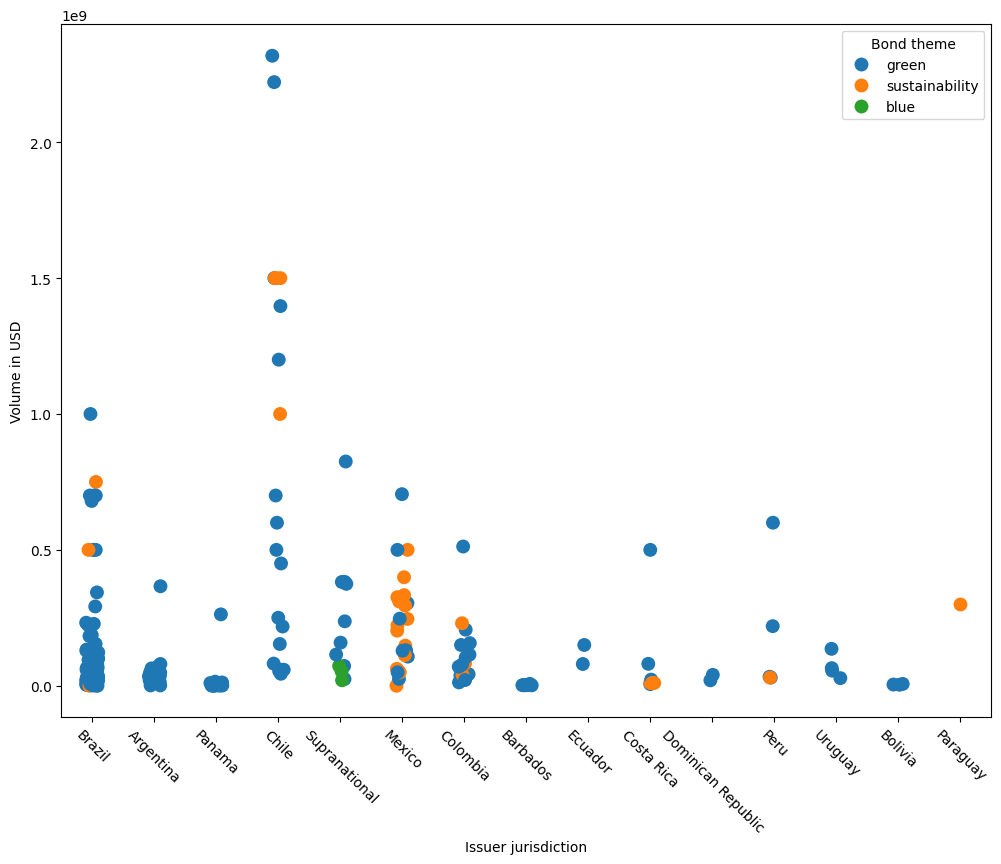

In [10]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='Issuer jurisdiction', y='Volume in USD', data= gbtp_bonds_df, hue='Bond theme', size=10)
plt.xticks(rotation=-45)

<Axes: xlabel='Volume in USD', ylabel='Issuer jurisdiction'>

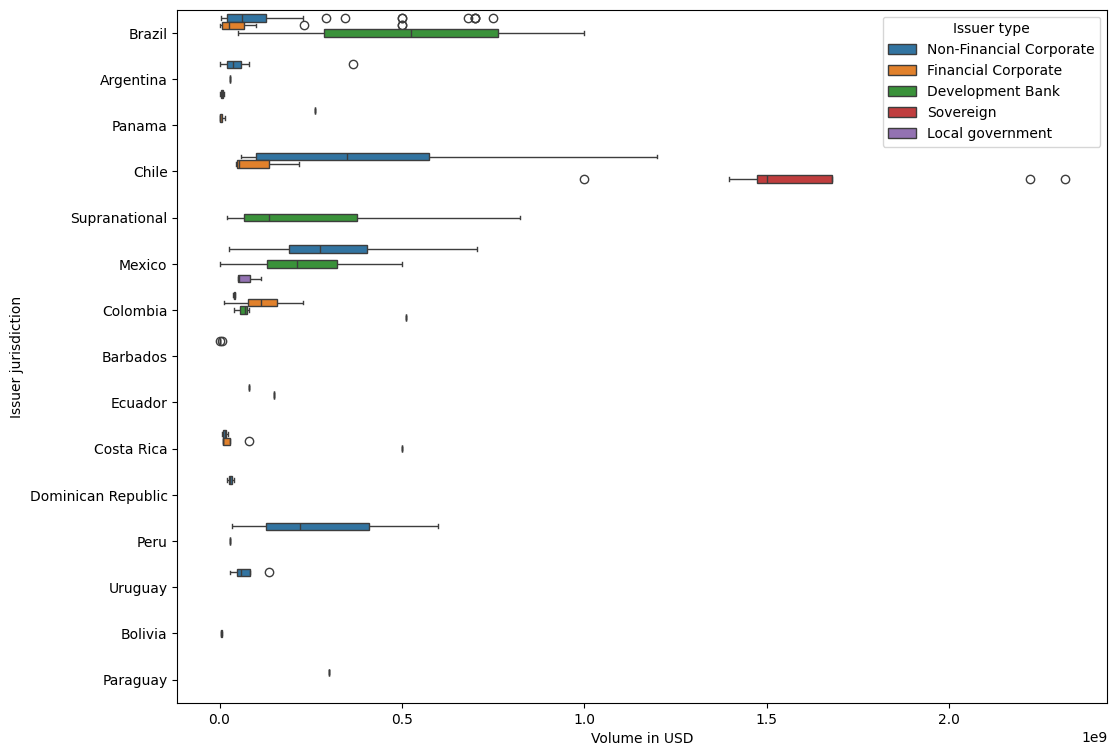

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.boxplot(gbtp_bonds_df, x='Volume in USD', y='Issuer jurisdiction', hue='Issuer type')

learn about time series / date functionality in pandas
Floor division is an arithmetic operation that divides two numbers and rounds the result down to the nearest whole number (integer)
epoch >> define

In [12]:
gbtp_bonds_df['Issuance date (date)'] = pd.to_datetime(gbtp_bonds_df['Issuance date (date)'])
gbtp_bonds_df['Maturity date (date)'] = pd.to_datetime(gbtp_bonds_df['Maturity date (date)'])
gbtp_bonds_df['Issuance date (epoch)'] = (gbtp_bonds_df['Issuance date (date)'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
gbtp_bonds_df['Maturity date (epoch)'] = (gbtp_bonds_df['Maturity date (date)'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
seconds_in_year = 365*24*60*60
gbtp_bonds_df['Maturity (years)'] = (gbtp_bonds_df['Maturity date (epoch)'] - gbtp_bonds_df['Issuance date (epoch)']) // seconds_in_year

gbtp_bonds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Link                     270 non-null    str           
 1   Handle                   270 non-null    str           
 2   ISIN                     225 non-null    str           
 3   FIGI                     115 non-null    str           
 4   CUSIP                    18 non-null     str           
 5   Ticker                   104 non-null    str           
 6   Name                     270 non-null    str           
 7   Fund                     270 non-null    str           
 8   Fund handle              76 non-null     str           
 9   Fund link                76 non-null     str           
 10  Issuance date (date)     249 non-null    datetime64[us]
 11  Maturity date (date)     258 non-null    datetime64[us]
 12  Last published (date)    132 non-null    str   

In [16]:
gbtp_bonds_df.head()

,Link,Handle,ISIN,FIGI,CUSIP,Ticker,Name,Fund,Fund handle,Fund link,...,Issuer name,Issuer type,Issuer jurisdiction,Framework link,Bond currency,Volume in bond currency,Volume in USD,Issuance date (epoch),Maturity date (epoch),Maturity (years)
0,https://www.greenbondtransparency.com/bond-inf...,9bd98e9cc0fd42a69775ddbd0c63147a,BRERENDBS073,NaN,NaN,NaN,Terceira Emissão De Debêntures Simples Da Eren...,No,NaN,NaN,...,Total Eren,Non-Financial Corporate,Brazil,NaN,BRL,280000000.0,6.515264e+07,1.581725e+09,2.136586e+09,17.0
1,https://www.greenbondtransparency.com/bond-inf...,e6bb16f3d1e04ba789445370e5e99dc0,ARENEY560035,NaN,NaN,GYC2D CLASE III,ON 360 ENERGY SOLAR CLASE 3,No,NaN,NaN,...,360 Energy Solar S.A.,Non-Financial Corporate,Argentina,NaN,USD,60000000.0,6.000000e+07,1.678234e+09,1.962317e+09,9.0
2,https://www.greenbondtransparency.com/bond-inf...,82f9c056cca1404e906b6d3270884a77,PAL3009913J3,NaN,NaN,NaN,CIFI Serie J,No,c8db70a600e4496aa0bdff98338e72ee,https://www.greenbondtransparency.com/bond-inf...,...,Corporación Interamericana para el Financiamie...,Financial Corporate,Panama,https://www.greenbondtransparency.com/download...,USD,2000000.0,2.000000e+06,1.603670e+09,1.698451e+09,3.0
3,https://www.greenbondtransparency.com/bond-inf...,3e001fbc60b6457dbbb4e67ee69152c0,CL0002521988,NaN,NaN,NaN,BAGUA-AE,No,NaN,NaN,...,Aguas Andinas,Non-Financial Corporate,Chile,https://www.greenbondtransparency.com/download...,CLF,2000000.0,8.150633e+07,1.554941e+09,2.341613e+09,24.0
4,https://www.greenbondtransparency.com/bond-inf...,14cdc800b4464301a71619d0ffe527a8,CH1191066278,BBG0180P8YS2,NaN,CABEI 1.5462 11,Second Swiss Green Bond,No,NaN,NaN,...,Central American Bank for Economic Integration...,Development Bank,Supranational,https://www.greenbondtransparency.com/download...,CHF,155000000.0,1.585840e+08,1.656547e+09,1.795997e+09,4.0


<Axes: xlabel='Maturity date (date)', ylabel='Density'>

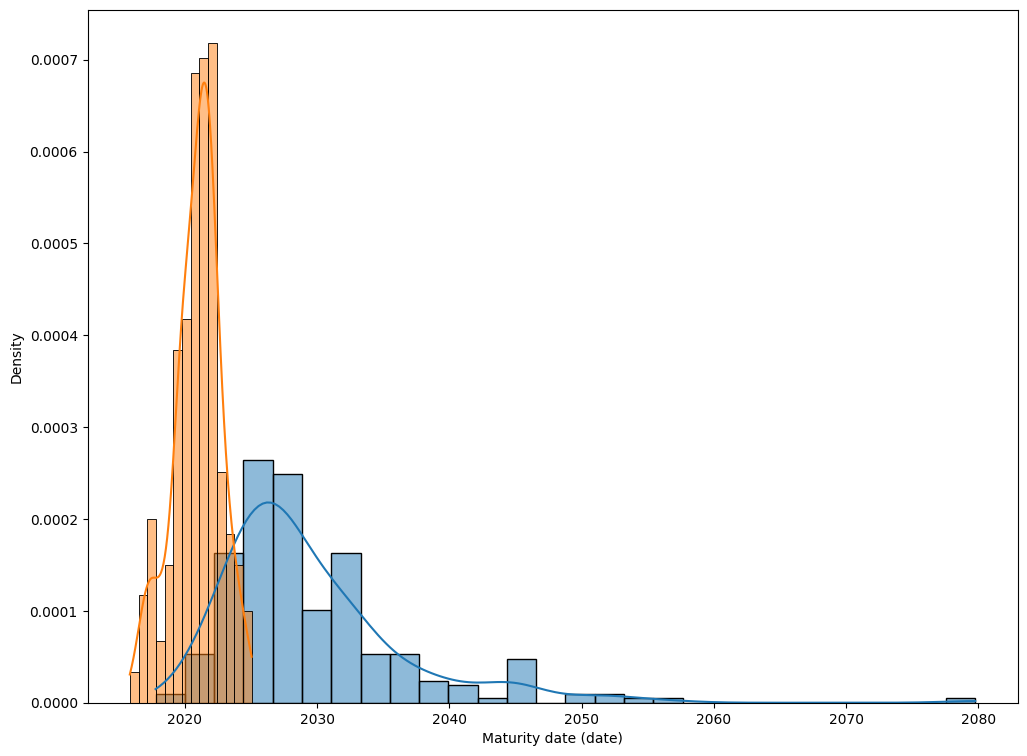

In [13]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.histplot(gbtp_bonds_df['Maturity date (date)'], stat='density',kde=True)
sns.histplot(gbtp_bonds_df['Issuance date (date)'], stat='density',kde=True)

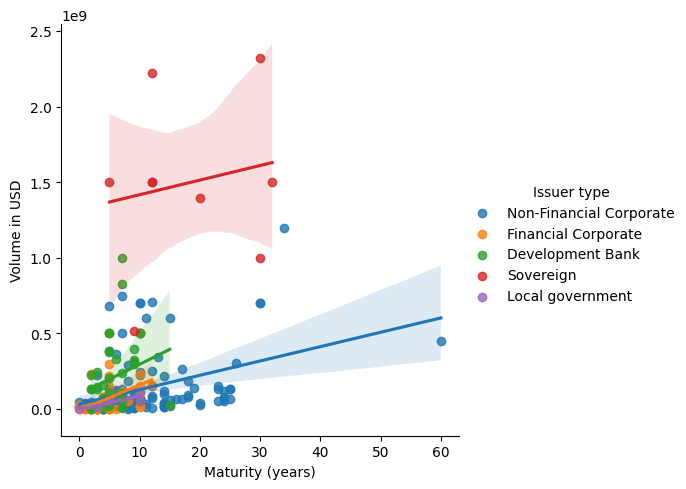

In [14]:
sns.lmplot(x='Maturity (years)', y='Volume in USD', data=gbtp_bonds_df, hue='Issuer type')

<Axes: xlabel='Maturity (years)', ylabel='Issuer jurisdiction'>

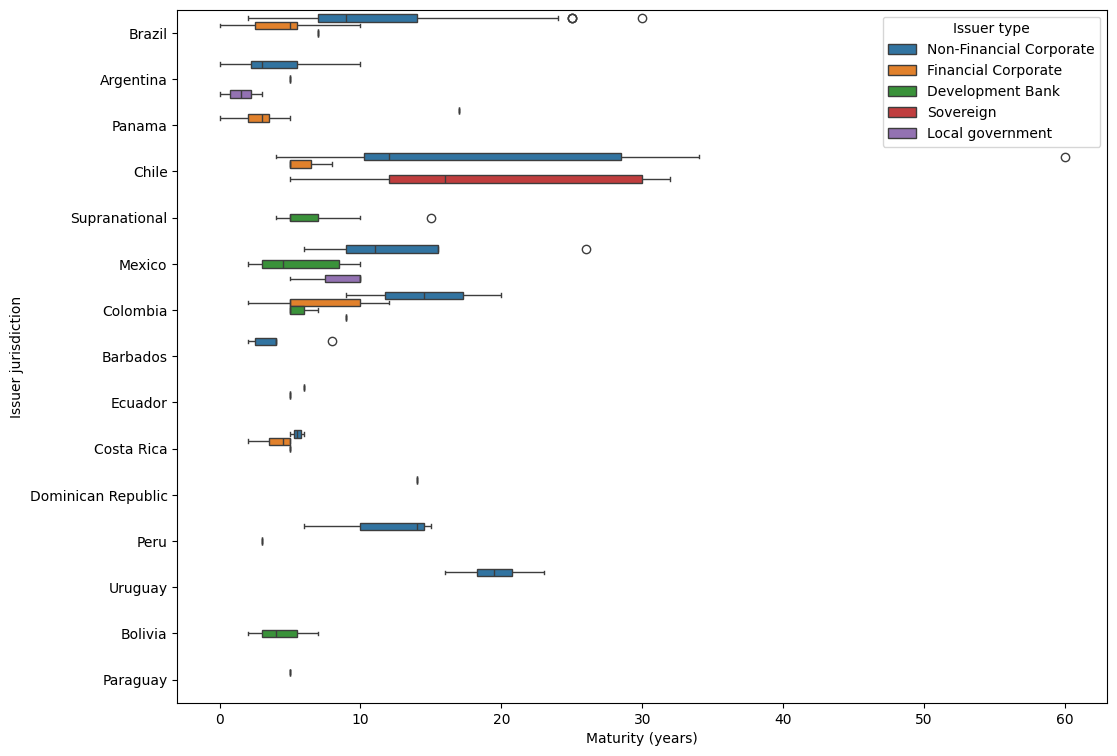

In [15]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.boxplot(gbtp_bonds_df, x='Maturity (years)', y='Issuer jurisdiction', hue='Issuer type')

total bonds - unique
non financial corp
green
has FW
has UoP (another file - the allocations file)

In [25]:
# boolean conditions

nfc = gbtp_bonds_df['Issuer type']=='Non-Financial Corporate'
green = gbtp_bonds_df['Bond theme']=='green'
new_gbtp_df = gbtp_bonds_df[nfc & green]
new_gbtp_df.info()

<class 'pandas.DataFrame'>
Index: 137 entries, 0 to 269
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Link                     137 non-null    str           
 1   Handle                   137 non-null    str           
 2   ISIN                     113 non-null    str           
 3   FIGI                     53 non-null     str           
 4   CUSIP                    9 non-null      str           
 5   Ticker                   62 non-null     str           
 6   Name                     137 non-null    str           
 7   Fund                     137 non-null    str           
 8   Fund handle              16 non-null     str           
 9   Fund link                16 non-null     str           
 10  Issuance date (date)     131 non-null    datetime64[us]
 11  Maturity date (date)     133 non-null    datetime64[us]
 12  Last published (date)    33 non-null     str        

In [28]:
new_gbtp_df['Name'].unique()

<StringArray>
['Terceira Emissão De Debêntures Simples Da Eren Dracena Participações S.A.',
                                               'ON 360 ENERGY SOLAR CLASE 3',
                                                                  'BAGUA-AE',
                                               'ON 360 ENERGY SOLAR CLASE 1',
                           'Certificado de Recebimento do Agronegócio (CRA)',
                                              'Título Sustentável Paranaguá',
           'Debêntures 12.431 - Central Hidrelétrica Palmeiras do Tocantins',
                                                             'WREL#1 Note B',
                  'Primeira Emissão de CRA Verde da Usina São Francisco S/A',
                     'Green Bond Rio Energy Serra da Babilonia Wind Complex',
 ...
                                                      'Green Bond CMPC 2017',
                                                                'AGUA 17-2x',
                                             

In [31]:
in_scope_handles = new_gbtp_df['Handle']
in_scope_handles.info()

<class 'pandas.Series'>
Index: 137 entries, 0 to 269
Series name: Handle
Non-Null Count  Dtype
--------------  -----
137 non-null    str  
dtypes: str(1)
memory usage: 2.1 KB


In [ ]:
pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
import openpyxl
in_scope_handles.to_excel('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/inScopeHandles.xlsx')
new_gbtp_df.to_excel('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/inScopeBonds.xlsx')

In [37]:
fnl_in_scope_handles = pd.read_csv('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/fnl_in_scope_handles.csv')
fnl_in_scope_handles_df = pd.DataFrame(fnl_in_scope_handles)

In [38]:
new_gbtp_df['In scope'] = new_gbtp_df['Handle'].isin(fnl_in_scope_handles_df['bond_handle'])

In [39]:
new_gbtp_df.to_excel('/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/inScopeBonds.xlsx')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'Argentina'),
  Text(2, 0, 'Chile'),
  Text(3, 0, 'Barbados'),
  Text(4, 0, 'Colombia'),
  Text(5, 0, 'Costa Rica'),
  Text(6, 0, 'Dominican Republic'),
  Text(7, 0, 'Mexico'),
  Text(8, 0, 'Peru'),
  Text(9, 0, 'Uruguay'),
  Text(10, 0, 'Ecuador'),
  Text(11, 0, 'Panama')])

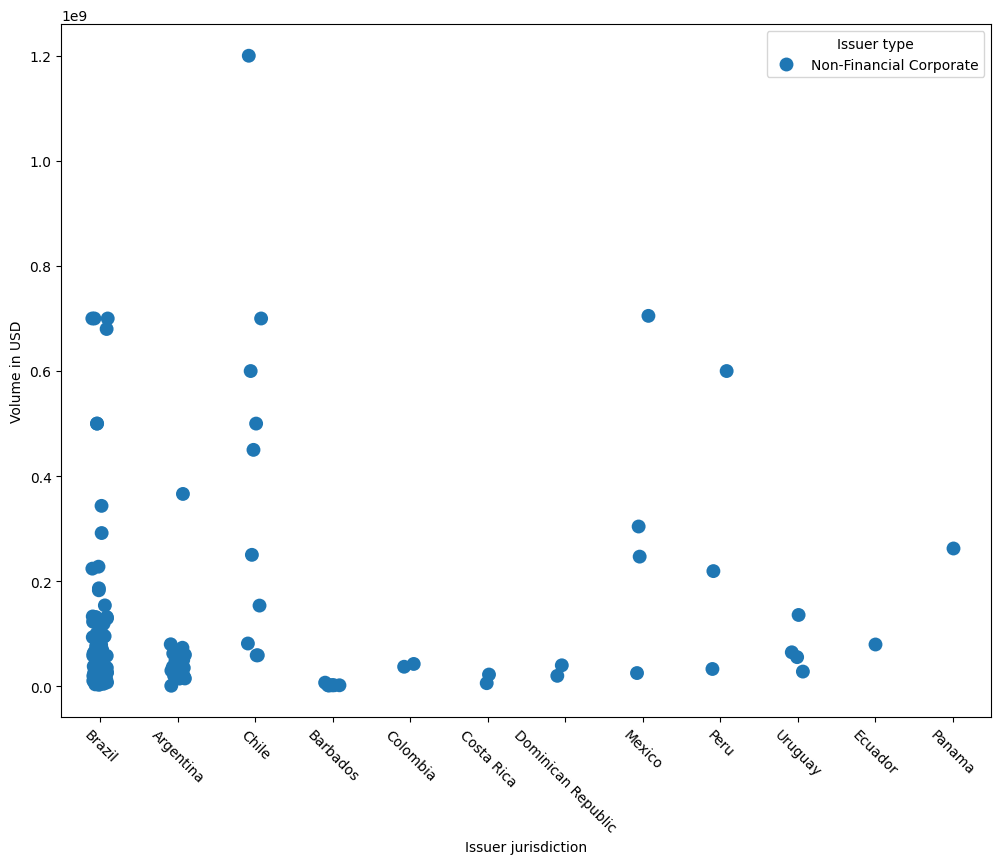

In [41]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='Issuer jurisdiction', y='Volume in USD', data= new_gbtp_df, hue='Issuer type', size=10)
plt.xticks(rotation=-45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'Argentina'),
  Text(2, 0, 'Chile'),
  Text(3, 0, 'Barbados'),
  Text(4, 0, 'Colombia'),
  Text(5, 0, 'Costa Rica'),
  Text(6, 0, 'Dominican Republic'),
  Text(7, 0, 'Mexico'),
  Text(8, 0, 'Peru'),
  Text(9, 0, 'Uruguay'),
  Text(10, 0, 'Ecuador'),
  Text(11, 0, 'Panama')])

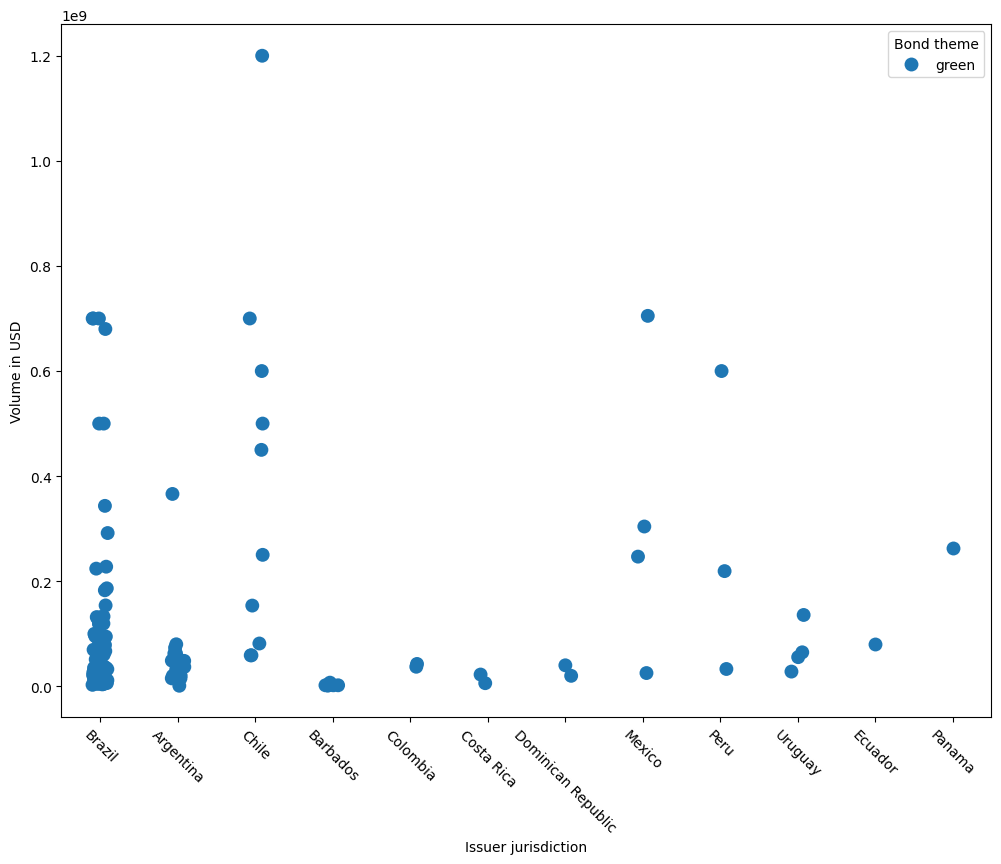

In [42]:
fig, ax = plt.subplots()
fig.set_size_inches(12,9)

sns.stripplot(x='Issuer jurisdiction', y='Volume in USD', data= new_gbtp_df, hue='Bond theme', size=10)
plt.xticks(rotation=-45)